In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
df = pd.read_csv('C:/Users/Raja shehbaz/Downloads/archive/players.csv')

# Data check karo
print("First 5 rows:")
df.head()

print("\nData Info:")
df.info()

Matplotlib is building the font cache; this may take a moment.


First 5 rows:

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1035 non-null   object 
 1   team                        1035 non-null   object 
 2   team_country                1035 non-null   object 
 3   position                    1035 non-null   object 
 4   age                         1035 non-null   object 
 5   birth_year                  1035 non-null   int64  
 6   club                        556 non-null    object 
 7   games                       1035 non-null   int64  
 8   games_starts                1035 non-null   int64  
 9   minutes                     627 non-null    float64
 10  minutes_90s                 627 non-null    float64
 11  goals                       627 non-null    float64
 12  assists                     627 non-null    float64
 13  goals_a

df.info() se pata chala ke data mein 1035 rows aur 72 columns hain. 
Kuch columns jaise pens_won aur gk wale columns mein missing values hain, 
jabke goals, assists, shots wale important columns complete hain.

In [2]:
# 1. Missing Values Check
print("Missing Values in each column:")
print(df.isnull().sum().sort_values(ascending=False))

# 2. Duplicate Rows Check
print("\nTotal Duplicate Rows:", df.duplicated().sum())

# 3. Duplicates hatao
df.drop_duplicates(inplace=True)

print("\nShape after removing duplicates:", df.shape)

Missing Values in each column:
pens_won            1035
pens_conceded       1035
gk_pens_save_pct    1032
gk_save_pct          996
gk_pens_saved        995
                    ... 
birth_year             0
age                    0
position               0
team_country           0
player                 0
Length: 72, dtype: int64

Total Duplicate Rows: 0

Shape after removing duplicates: (1035, 72)


Data cleaning step mein humne missing values aur duplicates check kiye. 
Total 0 duplicate rows mile isliye data already saaf tha. 
Kuch columns jaise pens_won aur gk_save_pct mein missing values hain, 
lekin humare analysis ke liye goals, assists, shots wale columns complete hain.

C:\Users\Raja shehbaz\AppData\Local\Temp\ipykernel_6300\23054133.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='goals', y='player', data=top_scorers, palette='viridis')


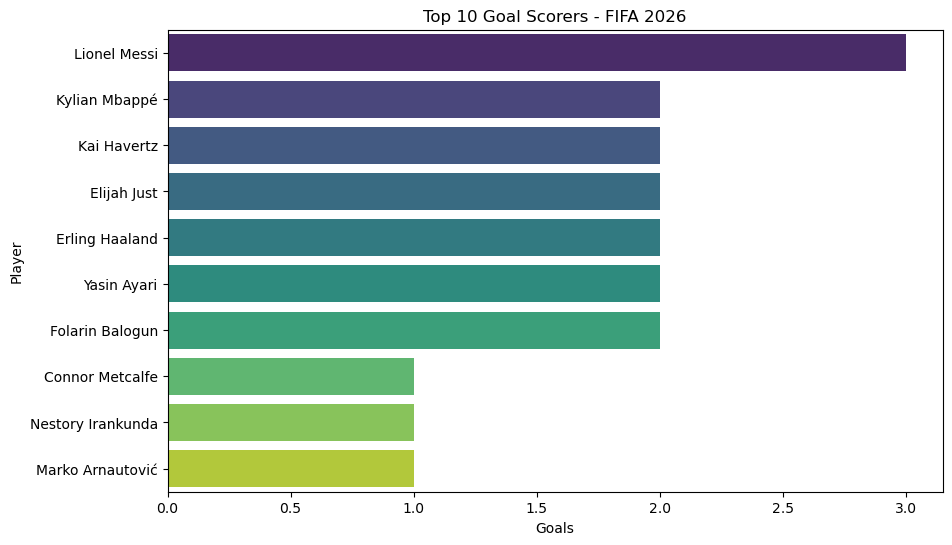


Top 10 Goal Scorers Data:


,player,team,goals
41,Lionel Messi,Argentina,3.0
371,Kylian Mbappé,France,2.0
401,Kai Havertz,Germany,2.0
655,Elijah Just,New Zealand,2.0
678,Erling Haaland,Norway,2.0
906,Yasin Ayari,Sweden,2.0
994,Folarin Balogun,United States,2.0
59,Connor Metcalfe,Australia,1.0
72,Nestory Irankunda,Australia,1.0
91,Marko Arnautović,Austria,1.0


In [3]:
# Top 10 Goal Scorers ka Bar Chart
top_scorers = df.nlargest(10, 'goals')

plt.figure(figsize=(10,6))
sns.barplot(x='goals', y='player', data=top_scorers, palette='viridis')
plt.title('Top 10 Goal Scorers - FIFA 2026')
plt.xlabel('Goals')
plt.ylabel('Player')
plt.show()

print("\nTop 10 Goal Scorers Data:")
top_scorers[['player', 'team', 'goals']]

Is table mein Top 10 Goal Scorers dikhaye gaye hain. 
Lionel Messi 3 goals ke sath sabse upar hai. 
Ye data player performance ko compare karne ke liye use kiya gaya hai.

In [5]:
print("Available Numeric Columns:")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

Available Numeric Columns:
['birth_year', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90', 'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90', 'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target', 'minutes_per_game', 'minutes_pct', 'minutes_per_start', 'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs', 'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus', 'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls', 'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won', 'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts', 'gk_minutes', 'gk_goals_against', 'gk_goals_against_per90', 'gk_shots_on_target_against', 'gk_saves', 'gk_save_pct', 'gk_wins', 'gk_ties', 'gk_losses', 'gk_clean_she

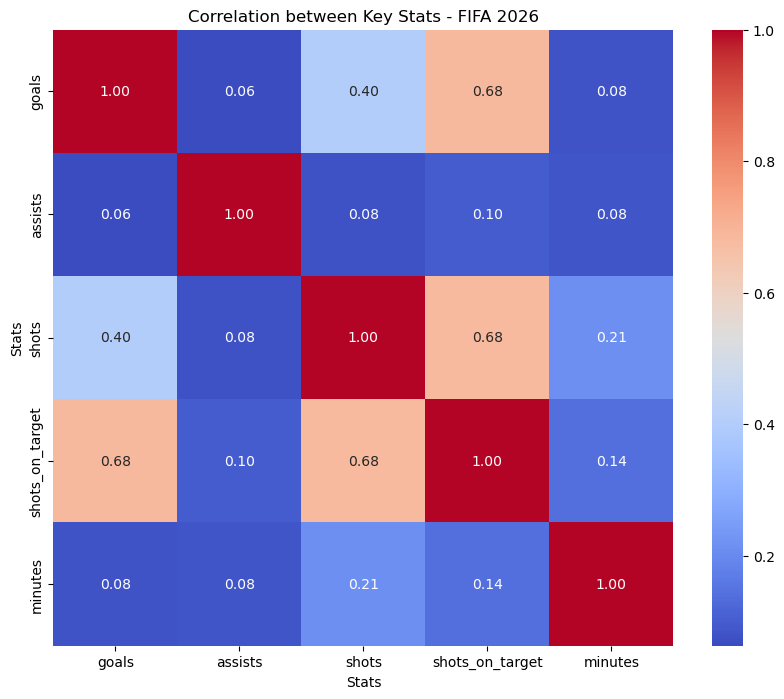

In [6]:
# Numeric columns select karo
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Jo columns dataset mein hain unka correlation
cols_to_use = ['goals', 'assists', 'shots', 'shots_on_target', 'minutes']
corr = numeric_df[cols_to_use].corr()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Key Stats - FIFA 2026')
plt.xlabel('Stats')
plt.ylabel('Stats')
plt.show()

Is correlation heatmap se pata chala ke goals ka sabse zyada connection 
shots_on_target se hai 0.68. 
Iska matlab hai ke target pe shots marne se hi goals badhte hain.
Sirf zyada shots marna kaafi nahi hai.